In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

ml_intensive_yandex_academy_spring_2026_path = kagglehub.competition_download('ml-intensive-yandex-academy-spring-2026')

print('Data source import complete.')


100%|██████████| 2.49G/2.49G [00:17<00:00, 152MB/s]

Extracting files...


Data source import complete.


In [ ]:
import os

os.listdir('/kaggle/input')

[]

In [ ]:
import warnings
import math

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms.v2 as T
from IPython.display import clear_output
from PIL import Image
from matplotlib import cm
from time import perf_counter
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
from tqdm import tqdm
from torch.optim import Optimizer
from torchsummary import summary
import pandas as pd

from torchvision.transforms.v2 import Compose, PILToTensor, ToDtype, Normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch.nn.functional as F

In [ ]:
ml_intensive_yandex_academy_spring_2026_path

'/root/.cache/kagglehub/competitions/ml-intensive-yandex-academy-spring-2026'

In [ ]:
main_dir = '/root/.cache/kagglehub/competitions/ml-intensive-yandex-academy-spring-2026'

In [ ]:
train_dir = main_dir + '/dataset/train_images'
test_dir = main_dir + '/dataset/test_images'
solution = main_dir + '/dataset/train_solution.csv'

In [ ]:
train_df = pd.read_csv(solution, header=None, names=['id', 'val'])
train_df = train_df.set_index('id')

In [ ]:
train_df['tmp_ind'] = train_df.index

In [ ]:
train_df['path'] = train_df['tmp_ind'].apply(lambda x: os.path.join(train_dir, str(x) + '.jpg'))

In [ ]:
train_df = train_df.drop('tmp_ind', axis=1)
train_df

,val,path
id,,
0,0,/root/.cache/kagglehub/competitions/ml-intensi...
1,1,/root/.cache/kagglehub/competitions/ml-intensi...
2,1,/root/.cache/kagglehub/competitions/ml-intensi...
3,0,/root/.cache/kagglehub/competitions/ml-intensi...
4,0,/root/.cache/kagglehub/competitions/ml-intensi...
...,...,...
49995,0,/root/.cache/kagglehub/competitions/ml-intensi...
49996,0,/root/.cache/kagglehub/competitions/ml-intensi...
49997,0,/root/.cache/kagglehub/competitions/ml-intensi...


In [ ]:
train_df

,val,path
id,,
0,0,/root/.cache/kagglehub/competitions/ml-intensi...
1,1,/root/.cache/kagglehub/competitions/ml-intensi...
2,1,/root/.cache/kagglehub/competitions/ml-intensi...
3,0,/root/.cache/kagglehub/competitions/ml-intensi...
4,0,/root/.cache/kagglehub/competitions/ml-intensi...
...,...,...
49995,0,/root/.cache/kagglehub/competitions/ml-intensi...
49996,0,/root/.cache/kagglehub/competitions/ml-intensi...
49997,0,/root/.cache/kagglehub/competitions/ml-intensi...


In [ ]:
def build_frequency_tensor(img_tensor: torch.Tensor) -> torch.Tensor:
    gray = img_tensor.mean(dim=0, keepdim=True)
    fft = torch.fft.fft2(gray)
    fft = torch.fft.fftshift(fft)
    magnitude = torch.log1p(torch.abs(fft))

    magnitude = magnitude - magnitude.mean()
    magnitude = magnitude / (magnitude.std(unbiased=False) + 1e-6)

    return magnitude.repeat(3, 1, 1)


class TrainDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        val = torch.tensor(row['val'], dtype=torch.long)

        if self.transform:
            img = self.transform(img)

        freq = build_frequency_tensor(img)
        return (img, freq), val

In [ ]:
class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.images = os.listdir(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        path = os.path.join(self.img_dir, img_name)

        img = Image.open(path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        freq = build_frequency_tensor(img)
        return (img, freq), img_name

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
])

In [ ]:
train_dataset = TrainDataset(train_df, train_transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_dataset = TestDataset(test_dir, test_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
device

device(type='cuda')

In [ ]:
class GradientReversalFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None


class AttentionFusion(nn.Module):
    def __init__(self, feature_dim=256):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, feature_dim),
            nn.Sigmoid()
        )

    def forward(self, spatial_feat, freq_feat):
        gate = self.gate(torch.cat([spatial_feat, freq_feat], dim=1))
        return gate * spatial_feat + (1.0 - gate) * freq_feat

In [ ]:
class FirstModel(nn.Module):
    def __init__(self, num_classes=2, feature_dim=256):
        super().__init__()

        self.spatial_branch = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )

        self.frequency_branch = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )

        self.fusion = AttentionFusion(feature_dim=feature_dim)

        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

        self.domain_head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, spatial, frequency, grl_lambda=0.0, return_domain=False):
        spatial_feat = self.spatial_branch(spatial)
        frequency_feat = self.frequency_branch(frequency)
        fused = self.fusion(spatial_feat, frequency_feat)
        logits = self.classifier(fused)

        if return_domain:
            reversed_feat = GradientReversalFn.apply(fused, grl_lambda)
            domain_logits = self.domain_head(reversed_feat)
            return logits, domain_logits

        return logits

In [ ]:
def _unpack_inputs(x):
    if isinstance(x, (tuple, list)) and len(x) == 2:
        return x[0], x[1]
    if isinstance(x, dict):
        return x["spatial"], x["frequency"]
    raise TypeError(x)

In [ ]:
def train_epoch(model, data_loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    all_preds, all_targets = [], []

    for x, y in tqdm(data_loader, desc="Training"):
        spatial, frequency = _unpack_inputs(x)
        spatial, frequency, y = spatial.to(device), frequency.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(spatial, frequency)
        if isinstance(output, tuple):
            output = output[0]

        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(output.argmax(dim=1).cpu().numpy())
        all_targets.extend(y.cpu().numpy())

    epoch_loss = total_loss / len(data_loader)
    epoch_f1 = f1_score(all_targets, all_preds, zero_division=0)
    return epoch_loss, epoch_f1

In [ ]:
@torch.inference_mode()
def evaluate_model(model, data_loader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []

    for x, y in data_loader:
        spatial, frequency = _unpack_inputs(x)
        spatial, frequency, y = spatial.to(device), frequency.to(device), y.to(device)

        output = model(spatial, frequency)
        if isinstance(output, tuple):
            output = output[0]

        loss = loss_fn(output, y)

        total_loss += loss.item()
        all_preds.extend(output.argmax(dim=1).cpu().numpy())
        all_targets.extend(y.cpu().numpy())

    val_loss = total_loss / len(data_loader)
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)

    metrics_df = pd.DataFrame({
        'Metric': ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Val': [round(val_loss, 4), round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)]
    })

    print(metrics_df)

    return val_loss, f1

In [ ]:
def plot_training_stats(train_loss, train_f1, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot(train_loss, label='Train Loss', color='blue')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(train_f1, label='Train F1-Score', color='blue')
    ax2.set_title(f'{title} - F1-Score')
    ax2.legend()
    ax2.grid(True)

    plt.show()

In [ ]:
def fit_model(
    model,
    train_loader,
    optimizer,
    loss_fn,
    device,
    num_epochs,
    title,
    scheduler=None,
):
    train_loss_history = []
    train_f1_history = []

    for epoch in range(num_epochs):
        print(f"\nЭпоха {epoch + 1}/{num_epochs}")
        train_loss, train_f1 = train_epoch(model, train_loader, optimizer, loss_fn, device)

        train_loss_history.append(train_loss)
        train_f1_history.append(train_f1)

        if scheduler is not None:
            scheduler.step()

        clear_output(wait=True)
        plot_training_stats(train_loss_history, train_f1_history, title)

    return train_loss_history, train_f1_history

In [ ]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

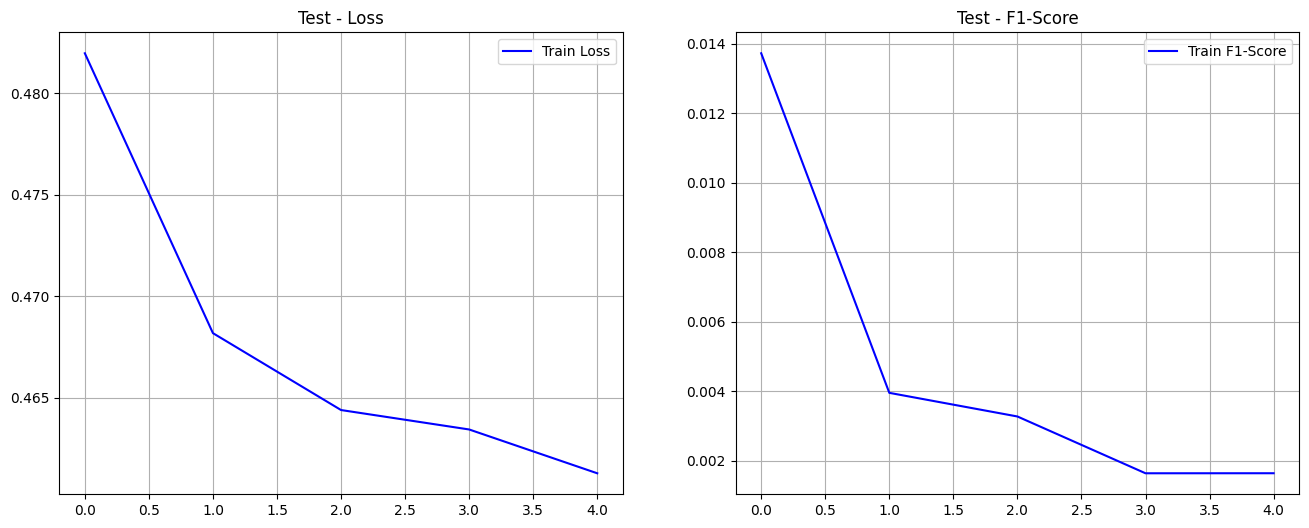


Эпоха 6/50


Training:  20%|█▉        | 154/782 [02:32<10:17,  1.02it/s]

In [ ]:
from torch.optim.lr_scheduler import StepLR

model = FirstModel().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

fit_model(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    num_epochs=50,
    title='Test',
    scheduler=scheduler
)